# CIA Landenanalyse en Clustering
Bron: Al deze datasets zijn samengesteld uit gegevens van de Amerikaanse overheid.
https://www.cia.gov/library/publications/the-world-factbook/docs/faqs.html

## Doel:
**Inzichten verkrijgen in de gelijkenis tussen landen en regio's van de wereld door te experimenteren met een verschillende aantal clusters.** <p>Zoek een interpretatie voor de clusters; maw wat vertegenwoordigen deze clusters? Let op: Er is geen 100% juist antwoord...</p>

----

## Importeren en Data
**OPDRACHT: Voer de volgende cellen uit om bibliotheken te importeren en gegevens in te lezen.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/CIA_Country_Facts.csv')

## Verkennende Data Analyse

**TAAK: Verken de rijen en kolommen van de gegevens, evenals de datatypes van de kolommen.**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             227 non-null    object 
 1   Region                              227 non-null    object 
 2   Population                          227 non-null    int64  
 3   Area (sq. mi.)                      227 non-null    int64  
 4   Pop. Density (per sq. mi.)          227 non-null    float64
 5   Coastline (coast/area ratio)        227 non-null    float64
 6   Net migration                       224 non-null    float64
 7   Infant mortality (per 1000 births)  224 non-null    float64
 8   GDP ($ per capita)                  226 non-null    float64
 9   Literacy (%)                        209 non-null    float64
 10  Phones (per 1000)                   223 non-null    float64
 11  Arable (%)                          225 non-n

In [4]:
df.describe()

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
count,2.270000e+02,2.270000e+02,227.000000,227.000000,224.000000,224.000000,226.000000,209.000000,223.000000,225.000000,225.000000,225.000000,205.000000,224.000000,223.000000,212.000000,211.000000,212.000000
mean,2.874028e+07,5.982270e+05,379.047137,21.165330,0.038125,35.506964,9689.823009,82.838278,236.061435,13.797111,4.564222,81.638311,2.139024,22.114732,9.241345,0.150844,0.282711,0.565283
std,1.178913e+08,1.790282e+06,1660.185825,72.286863,4.889269,35.389899,10049.138513,19.722173,227.991829,13.040402,8.361470,16.140835,0.699397,11.176716,4.990026,0.146798,0.138272,0.165841
min,7.026000e+03,2.000000e+00,0.000000,0.000000,-20.990000,2.290000,500.000000,17.600000,0.200000,0.000000,0.000000,33.330000,1.000000,7.290000,2.290000,0.000000,0.020000,0.062000
25%,4.376240e+05,4.647500e+03,29.150000,0.100000,-0.927500,8.150000,1900.000000,70.600000,37.800000,3.220000,0.190000,71.650000,2.000000,12.672500,5.910000,0.037750,0.193000,0.429250
50%,4.786994e+06,8.660000e+04,78.800000,0.730000,0.000000,21.000000,5550.000000,92.500000,176.200000,10.420000,1.030000,85.700000,2.000000,18.790000,7.840000,0.099000,0.272000,0.571000
75%,1.749777e+07,4.418110e+05,190.150000,10.345000,0.997500,55.705000,15700.000000,98.000000,389.650000,20.000000,4.440000,95.440000,3.000000,29.820000,10.605000,0.221000,0.341000,0.678500
max,1.313974e+09,1.707520e+07,16271.500000,870.660000,23.060000,191.190000,55100.000000,100.000000,1035.600000,62.110000,50.680000,100.000000,4.000000,50.730000,29.740000,0.769000,0.906000,0.954000


In [8]:
df.sample(5).T

,117,34,194,102,19
Country,Liberia,Cambodia,Swaziland,Jamaica,Belgium
Region,SUB-SAHARAN AFRICA,ASIA (EX. NEAR EAST),SUB-SAHARAN AFRICA,LATIN AMER. & CARIB,WESTERN EUROPE
Population,3042004,13881427,1136334,2758124,10379067
Area (sq. mi.),111370,181040,17363,10991,30528
Pop. Density (per sq. mi.),27.3,76.7,65.5,250.9,340.0
Coastline (coast/area ratio),0.52,0.24,0.0,9.3,0.22
Net migration,0.0,0.0,0.0,-4.92,1.23
Infant mortality (per 1000 births),128.87,71.48,69.27,12.36,4.68
GDP ($ per capita),1000.0,1900.0,4900.0,3900.0,29100.0
Literacy (%),57.5,69.4,81.6,87.9,98.0


## Laat ons enkele grafieken maken.  Voel je vrij om dit deel uit te breiden met eigen analyse en grafieken!

**TAAK: Maak een histogram van de Population kolom.**

<Axes: xlabel='Population', ylabel='Count'>

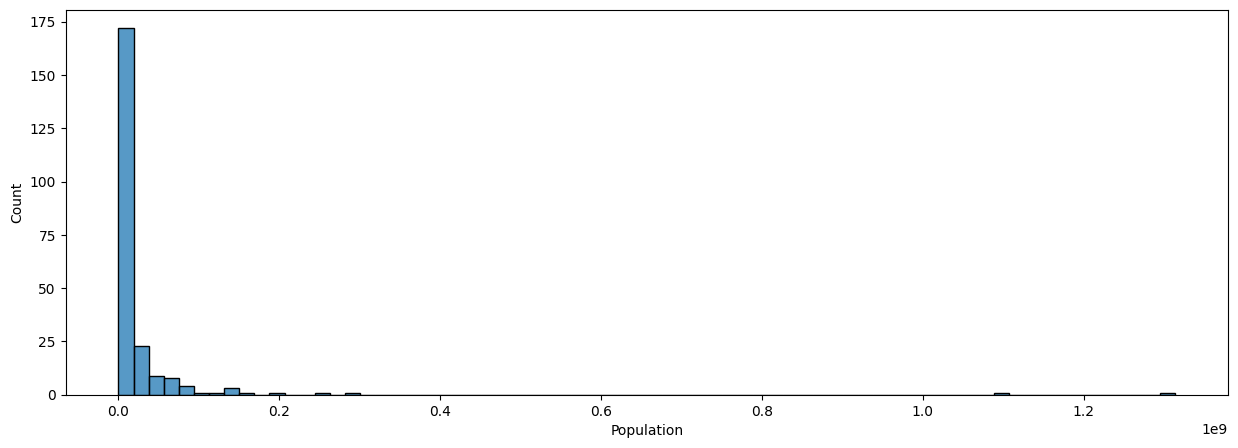

In [15]:
plt.figure(figsize=(15, 5))
sns.histplot(data=df, x='Population', bins=70)

**TAAK: Je ziet dat het histogram skewed (scheef) is omwille van een aantal grote landen.  Reset de X as om enkel landen te tonen die minder dan 0.5 miljard inwoners hebben.**

<Axes: xlabel='Population', ylabel='Count'>

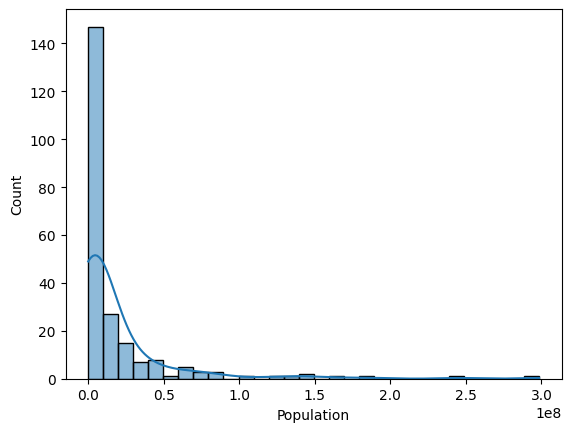

In [16]:
sns.histplot(data=df[df['Population']<500000000], x='Population', kde=True)

**TAAK: Laat ons nu GDP en Regions bekijken.  Maak een bar chart die het gemiddelde GDP per Capita per region toont.**

In [17]:
df.columns

Index(['Country', 'Region', 'Population', 'Area (sq. mi.)',
       'Pop. Density (per sq. mi.)', 'Coastline (coast/area ratio)',
       'Net migration', 'Infant mortality (per 1000 births)',
       'GDP ($ per capita)', 'Literacy (%)', 'Phones (per 1000)', 'Arable (%)',
       'Crops (%)', 'Other (%)', 'Climate', 'Birthrate', 'Deathrate',
       'Agriculture', 'Industry', 'Service'],
      dtype='object')

In [ ]:
df.Region = df.Region.str.strip() # OCD :)
df.Region.unique()

array(['ASIA (EX. NEAR EAST)', 'EASTERN EUROPE', 'NORTHERN AFRICA',
       'OCEANIA', 'WESTERN EUROPE', 'SUB-SAHARAN AFRICA',
       'LATIN AMER. & CARIB', 'C.W. OF IND. STATES', 'NEAR EAST',
       'NORTHERN AMERICA', 'BALTICS'], dtype=object)

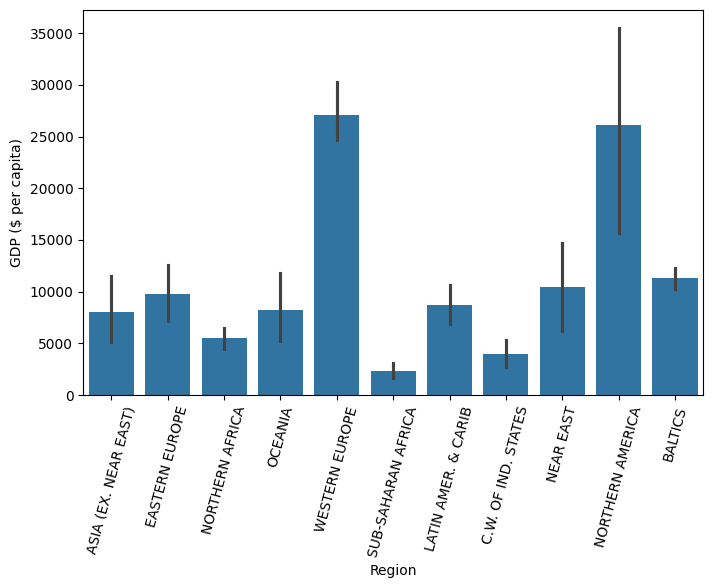

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Region", y="GDP ($ per capita)", estimator=np.mean)
plt.xticks(rotation=75)
plt.show()

**TAAK: Maak een spreidingsdiagram dat de relatie weergeeft tussen het aantal telefoons (Phones) per 1000 mensen en het BBP per capita. Kleur deze punten in op basis van de regio.**

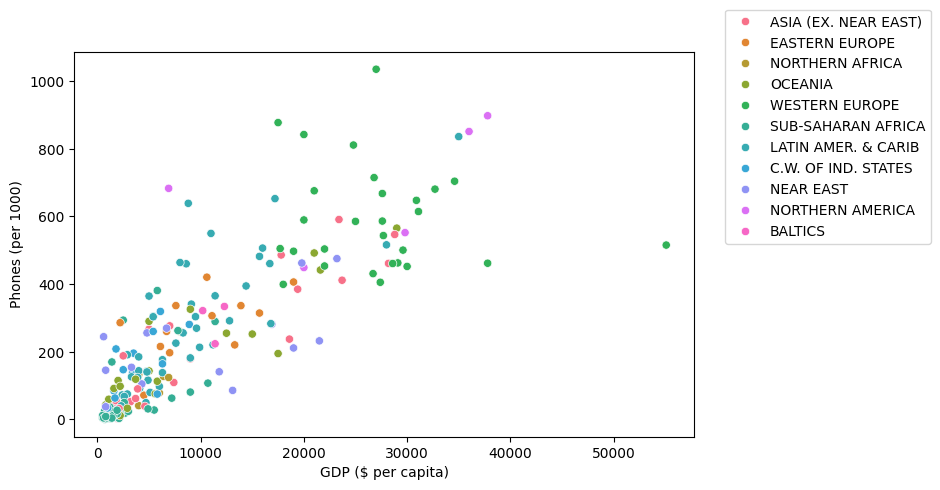

In [33]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='GDP ($ per capita)', y='Phones (per 1000)', hue='Region')
plt.legend(loc=(1.05, 0.5))

In [ ]:
df[df['Phones (per 1000)']>1000].Country

138    Monaco
Name: Country, dtype: object


In [38]:
df[df['GDP ($ per capita)']>50000].Country

121    Luxembourg
Name: Country, dtype: object

**TAAK: Maak een spreidingsdiagram dat de relatie toont tussen het BBP per capita en geletterdheid (kleur de punten op basis van regio). Welke conclusies trek je uit deze grafiek?**

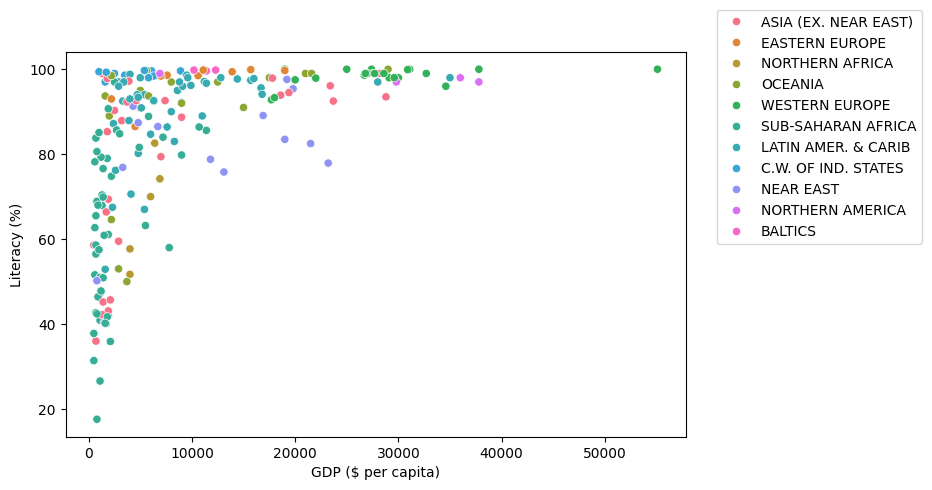

In [40]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='GDP ($ per capita)', y='Literacy (%)', hue='Region')
plt.legend(loc=(1.05, 0.5))

Vanaf de treshold van BBP rond 10000$ hebben zo goed als alle landen een geletterdheid van minstens 80%. Bij armere landen zien we zo goed als elke graad van geletterdheid.

**TAAK: Maak een heatmap van de Correlatie tussen kolommen in het DataFrame.**

<Axes: >

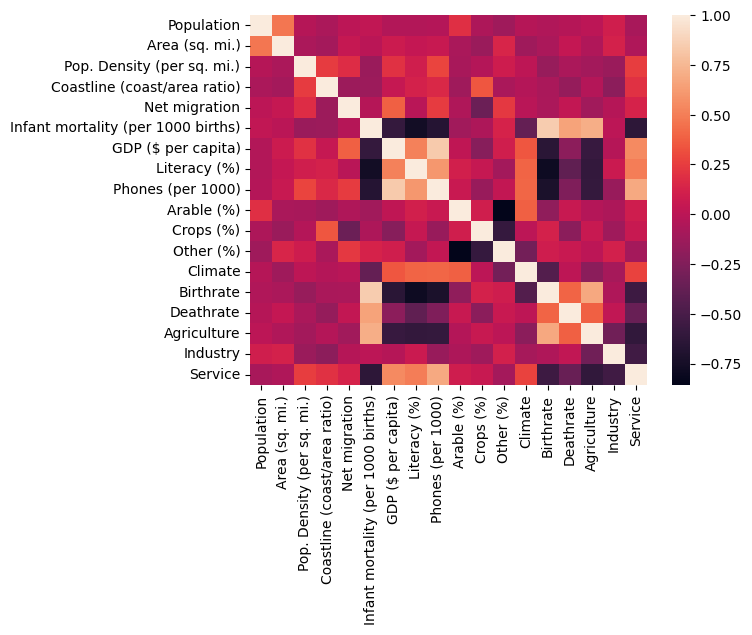

In [43]:
#plt.figure(dpi=200)
corr = df.corr(numeric_only=True)
sns.heatmap(corr)

Hoge correlatie tussen infant mortality en birthrate, o.a.

**TAAK: Seaborn kan op automatische wijze hierarchisch clusteren via de clustermap() functie. Maak een clustermap van de correlaties tussen alle kolommen met behulp van deze functie.**

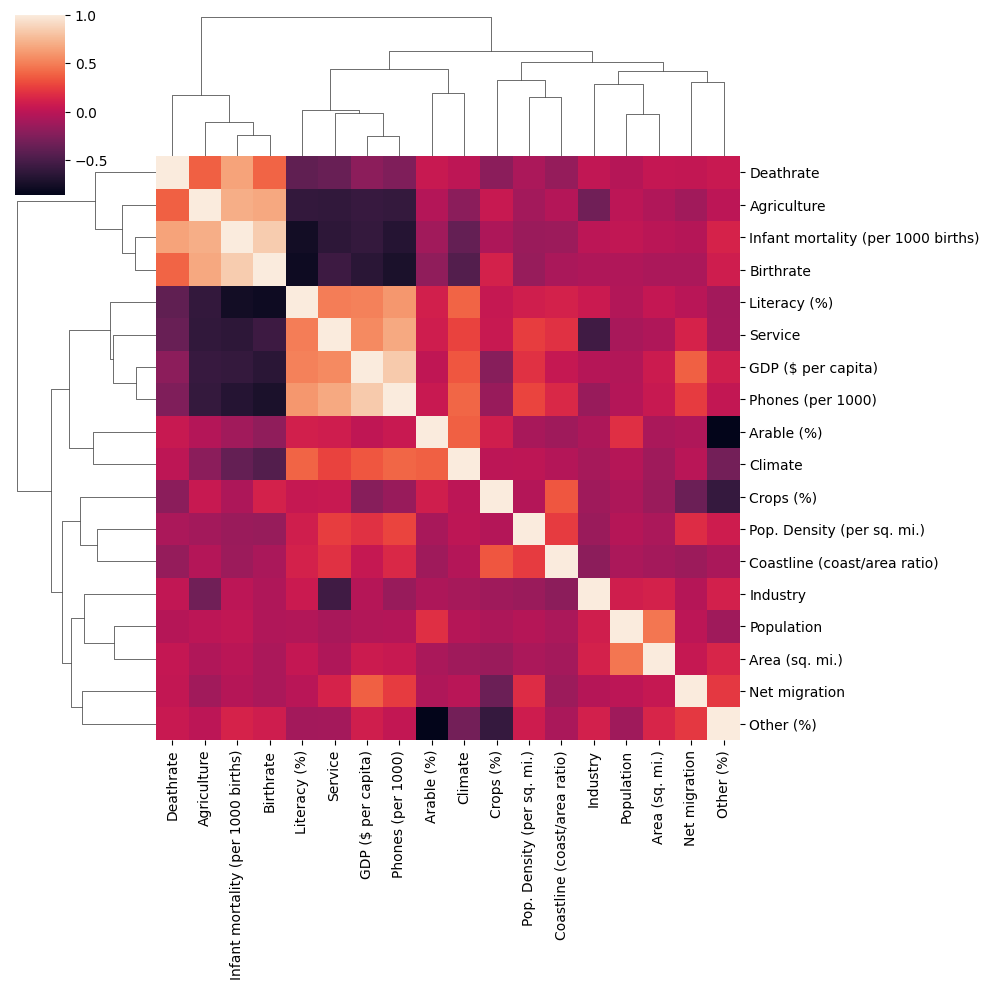

In [45]:
sns.clustermap(corr);

-----

## Voorbereiding van data en Model

We bereiden nu de data voor om Kmeans Clustering te kunnen toepassen!

### Ontbrekende Data

**TAAK: Geef het aantal ontbrekende elementen per kolom weer.**

In [46]:
df.isnull().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                          18
Phones (per 1000)                      4
Arable (%)                             2
Crops (%)                              2
Other (%)                              2
Climate                               22
Birthrate                              3
Deathrate                              4
Agriculture                           15
Industry                              16
Service                               15
dtype: int64

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                          18
Phones (per 1000)                      4
Arable (%)                             2
Crops (%)                              2
Other (%)                              2
Climate                               22
Birthrate                              3
Deathrate                              4
Agriculture                           15
Industry                              16
Service                               15
dtype: int64

**TAAK: Welke landen hebben NaN voor Agriculture? Wat is het voornaamste kenmerk van deze landen?**

In [48]:
df[df.Agriculture.isnull()].Country

3            American Samoa
4                   Andorra
78                Gibraltar
80                Greenland
83                     Guam
134                 Mayotte
140              Montserrat
144                   Nauru
153      N. Mariana Islands
171            Saint Helena
174    St Pierre & Miquelon
177              San Marino
208       Turks & Caicos Is
221       Wallis and Futuna
223          Western Sahara
Name: Country, dtype: object

3            American Samoa
4                   Andorra
78                Gibraltar
80                Greenland
83                     Guam
134                 Mayotte
140              Montserrat
144                   Nauru
153      N. Mariana Islands
171            Saint Helena
174    St Pierre & Miquelon
177              San Marino
208       Turks & Caicos Is
221       Wallis and Futuna
223          Western Sahara
Name: Country, dtype: object

**TAAK: Je zou gemerkt moeten hebben dat de meeste van deze landen kleine eilanden zijn, met uitzondering van Groenland en Westelijke Sahara. Ga je gang en vul eventuele ontbrekende NaN-waarden van deze landen in met 0, aangezien ze zo klein zijn of in wezen niet bestaan. Dit zou je in totaal voor 15 landen moeten doen. Voor een hint over hoe je dit kunt doen, herinner je dat je het volgende kunt doen:**

    df[df['feature'].isnull()]
    

In [49]:
df[df.Agriculture.isnull()] = df[df.Agriculture.isnull()].fillna(0)

In [50]:
df[df.Agriculture.isnull()].Country

Series([], Name: Country, dtype: object)

**TAAK: Controleer nu wat er nog ontbreekt door opnieuw het aantal ontbrekende elementen per feature te tellen:**

In [51]:
df.isnull().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          1
Infant mortality (per 1000 births)     1
GDP ($ per capita)                     0
Literacy (%)                          13
Phones (per 1000)                      2
Arable (%)                             1
Crops (%)                              1
Other (%)                              1
Climate                               18
Birthrate                              1
Deathrate                              2
Agriculture                            0
Industry                               1
Service                                1
dtype: int64

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          1
Infant mortality (per 1000 births)     1
GDP ($ per capita)                     0
Literacy (%)                          13
Phones (per 1000)                      2
Arable (%)                             1
Crops (%)                              1
Other (%)                              1
Climate                               18
Birthrate                              1
Deathrate                              2
Agriculture                            0
Industry                               1
Service                                1
dtype: int64

**TAAK: Merk op dat het klimaat ontbreekt voor een aantal landen, maar niet de Regio! Laten we dit in ons voordeel gebruiken. Vul de ontbrekende klimaatwaarden in op basis van de gemiddelde klimaatwaarde voor de betreffende regio.**

Hints hoe je dit kan doen: https://stackoverflow.com/questions/19966018/pandas-filling-missing-values-by-mean-in-each-group


In [55]:
df[df.Climate.isnull()].Country

5             Angola
36            Canada
50           Croatia
66     Faroe Islands
101            Italy
115          Lebanon
118            Libya
120        Lithuania
121       Luxembourg
129            Malta
137          Moldova
138           Monaco
141          Morocco
145            Nepal
169           Russia
181           Serbia
186         Slovenia
200         Tanzania
Name: Country, dtype: object

In [56]:
df['Climate'] = df.Climate.fillna(df.groupby('Region').Climate.transform('mean'))

**TAAK: Controleer opnieuw hoeveel ontbrekende waarden er zijn per feature:**

In [57]:
df.isnull().sum()

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          1
Infant mortality (per 1000 births)     1
GDP ($ per capita)                     0
Literacy (%)                          13
Phones (per 1000)                      2
Arable (%)                             1
Crops (%)                              1
Other (%)                              1
Climate                                0
Birthrate                              1
Deathrate                              2
Agriculture                            0
Industry                               1
Service                                1
dtype: int64

Country                                0
Region                                 0
Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          1
Infant mortality (per 1000 births)     1
GDP ($ per capita)                     0
Literacy (%)                          13
Phones (per 1000)                      2
Arable (%)                             1
Crops (%)                              1
Other (%)                              1
Climate                                0
Birthrate                              1
Deathrate                              2
Agriculture                            0
Industry                               1
Service                                1
dtype: int64

**TAAK: Het lijkt erop dat het percentage geletterdheid ontbreekt. Gebruik dezelfde tactiek als we deden met ontbrekende klimaatwaarden en vul eventuele ontbrekende waarden voor het percentage geletterdheid in met het gemiddelde percentage geletterdheid van de regio.**

In [ ]:
#CODE HERE

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
25,Bosnia & Herzegovina,EASTERN EUROPE,4498976,51129,88.0,0.04,0.31,21.05,6100.0,NaN,215.4,13.60,2.96,83.44,4.000000,8.77,8.27,0.142,0.308,0.550
66,Faroe Islands,WESTERN EUROPE,47246,1399,33.8,79.84,1.41,6.24,22000.0,NaN,503.8,2.14,0.00,97.86,2.826087,14.05,8.70,0.270,0.110,0.620
74,Gaza Strip,NEAR EAST,1428757,360,3968.8,11.11,1.60,22.93,600.0,NaN,244.3,28.95,21.05,50.00,3.000000,39.45,3.80,0.030,0.283,0.687
85,Guernsey,WESTERN EUROPE,65409,78,838.6,64.10,3.84,4.71,20000.0,NaN,842.4,NaN,NaN,NaN,3.000000,8.81,10.01,0.030,0.100,0.870
99,Isle of Man,WESTERN EUROPE,75441,572,131.9,27.97,5.36,5.93,21000.0,NaN,676.0,9.00,0.00,91.00,3.000000,11.05,11.19,0.010,0.130,0.860
104,Jersey,WESTERN EUROPE,91084,116,785.2,60.34,2.76,5.24,24800.0,NaN,811.3,0.00,0.00,100.00,3.000000,9.30,9.28,0.050,0.020,0.930
108,Kiribati,OCEANIA,105432,811,130.0,140.94,0.00,48.52,800.0,NaN,42.7,2.74,50.68,46.58,2.000000,30.65,8.26,0.089,0.242,0.668
123,Macedonia,EASTERN EUROPE,2050554,25333,80.9,0.00,-1.45,10.09,6700.0,NaN,260.0,22.26,1.81,75.93,3.000000,12.02,8.77,0.118,0.319,0.563
185,Slovakia,EASTERN EUROPE,5439448,48845,111.4,0.00,0.30,7.41,13300.0,NaN,220.1,30.16,2.62,67.22,3.000000,10.65,9.45,0.035,0.294,0.672
187,Solomon Islands,OCEANIA,552438,28450,19.4,18.67,0.00,21.29,1700.0,NaN,13.4,0.64,2.00,97.36,2.000000,30.01,3.92,0.420,0.110,0.470


**TAAK: Controleer opnieuw de ontbrekende waarden:**

Country                               0
Region                                0
Population                            0
Area (sq. mi.)                        0
Pop. Density (per sq. mi.)            0
Coastline (coast/area ratio)          0
Net migration                         1
Infant mortality (per 1000 births)    1
GDP ($ per capita)                    0
Literacy (%)                          0
Phones (per 1000)                     2
Arable (%)                            1
Crops (%)                             1
Other (%)                             1
Climate                               0
Birthrate                             1
Deathrate                             2
Agriculture                           0
Industry                              1
Service                               1
dtype: int64

**TAAK: Optioneel: We missen nu alleen nog waarden voor een paar landen. Ga je gang en verwijder deze landen of vul deze laatste paar ontbrekende waarden in met een door jou gekozen methode. Voor de eenvoud zullen we deze landen verwijderen.**

In [ ]:
# CODE HERE

## Data Feature Voorbereiding

**TAAK: Het is nu tijd om de gegevens voor clustering voor te bereiden. De kolom Land is nog steeds een unieke identificatie string, dus het zal niet nuttig zijn voor clustering, aangezien het uniek is voor elk punt. Ga je gang en verwijder deze kolom Land.**

In [ ]:
#CODE HERE

**TAAK: Laten we nu de X-array van de features creëren; de kolom Regio bestaat nog steeds uit categorische strings. Gebruik Pandas om dummyvariabelen van deze kolom te maken om een gefinaliseerde X-matrix van continue features te creëren, samen met de dummyvariabelen voor de Regio's.**

In [ ]:
#Code here

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),...,Region_BALTICS,Region_C.W. OF IND. STATES,Region_EASTERN EUROPE,Region_LATIN AMER. & CARIB,Region_NEAR EAST,Region_NORTHERN AFRICA,Region_NORTHERN AMERICA,Region_OCEANIA,Region_SUB-SAHARAN AFRICA,Region_WESTERN EUROPE
0,31056997,647500,48.0,0.00,23.06,163.07,700.0,36.0,3.2,12.13,...,0,0,0,0,0,0,0,0,0,0
1,3581655,28748,124.6,1.26,-4.93,21.52,4500.0,86.5,71.2,21.09,...,0,0,1,0,0,0,0,0,0,0
2,32930091,2381740,13.8,0.04,-0.39,31.00,6000.0,70.0,78.1,3.22,...,0,0,0,0,0,1,0,0,0,0
3,57794,199,290.4,58.29,-20.71,9.27,8000.0,97.0,259.5,10.00,...,0,0,0,0,0,0,0,1,0,0
4,71201,468,152.1,0.00,6.60,4.05,19000.0,100.0,497.2,2.22,...,0,0,0,0,0,0,0,0,0,1


### Scaling

**TAAK: Aangezien sommige metingen in % zijn en andere total counts zijn (populatie), moeten we de data schalen.  Gebruik Sklearn om de X features te schalen.**

In [ ]:
#CODE HERE

array([[ 0.0133285 ,  0.01855412, -0.20308668, ..., -0.31544015,
        -0.54772256, -0.36514837],
       [-0.21730118, -0.32370888, -0.14378531, ..., -0.31544015,
        -0.54772256, -0.36514837],
       [ 0.02905136,  0.97784988, -0.22956327, ..., -0.31544015,
        -0.54772256, -0.36514837],
       ...,
       [-0.06726127, -0.04756396, -0.20881553, ..., -0.31544015,
        -0.54772256, -0.36514837],
       [-0.15081724,  0.07669798, -0.22840201, ..., -0.31544015,
         1.82574186, -0.36514837],
       [-0.14464933, -0.12356132, -0.2160153 , ..., -0.31544015,
         1.82574186, -0.36514837]])

### Maken en Fitten van een Kmeans Model

**TAAK: Gebruik een for-loop om meerdere KMeans-modellen te creëren en te fitten, waarbij je test van K=2 tot K=30 clusters. Houd de som van de gekwadrateerde afstanden bij voor elke K-waarde en plot deze om een "elleboog"-grafiek te maken van K versus SSD. Optioneel: Je kunt ook een staafdiagram maken dat het verschil in SSD toont ten opzichte van de vorige cluster.**

In [ ]:
#CODE HERE

Text(0, 0.5, ' Sum of Squared Distances')

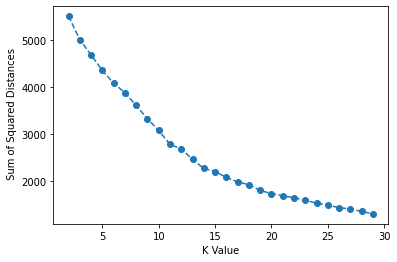

<AxesSubplot:>

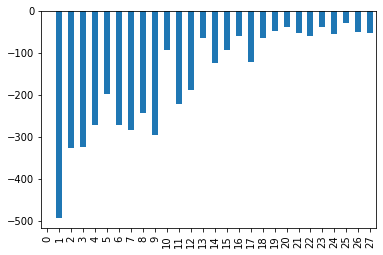

-----

# Interpretatie van het Model


**Welke K-waarde denk je dat een goede keuze is? Zijn er meerdere redelijke keuzes? Welke kenmerken helpen bij het definiëren van deze clusterkeuzes? Aangezien dit unsupervised learning is, is er hier geen 100% correct antwoord. Dit wordt later ook besproken in de oplossing!**

In [ ]:
# Er is hier niets om echt te programmeren, maar kies een K-waarde en bekijk welke features
# het sterkst gecorreleerd zijn aan een bepaalde cluster.

# Onthoud, er is hier geen 100% correct antwoord!

-----


#### Voorbeeld interpretatie: Kies K=3

**Men zou kunnen zeggen dat er een aanzienlijke afname is in het SSD-verschil bij K=3 (hoewel we kunnen zien dat het daarna blijft afnemen). Hoe zou een analyse eruitzien voor K=3? Laten we onderzoeken welke kenmerken belangrijk zijn in de beslissing van 3 clusters.!**

KMeans(n_clusters=3)

array([2, 0, 0, 0, 1, 2, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 2, 1, 1, 1, 0, 2,
       1, 2, 0, 1, 2, 0, 1, 0, 1, 2, 2, 2, 2, 2, 1, 0, 1, 2, 2, 0, 0, 0,
       2, 2, 2, 0, 2, 1, 0, 1, 1, 2, 0, 0, 0, 0, 0, 2, 2, 1, 2, 1, 0, 1,
       1, 0, 0, 2, 2, 0, 0, 1, 2, 1, 1, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 0, 0, 1, 0, 0, 2,
       1, 0, 2, 2, 0, 1, 1, 1, 1, 1, 2, 2, 0, 0, 2, 1, 0, 0, 2, 0, 2, 0,
       0, 0, 0, 0, 0, 2, 2, 0, 2, 1, 0, 0, 1, 0, 2, 2, 0, 1, 0, 2, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2,
       0, 2, 1, 1, 1, 0, 2, 2, 1, 0, 2, 0, 2, 1, 1, 0, 1, 0, 2, 0, 2, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2,
       2])

Literacy (%)                                 -0.419453
Region_LATIN AMER. & CARIB                   -0.377533
Region_OCEANIA                               -0.248224
Crops (%)                                    -0.245934
Phones (per 1000)                            -0.198737
Region_C.W. OF IND. STATES                   -0.193384
Region_NEAR EAST                             -0.179732
Coastline (coast/area ratio)                 -0.158318
Region_NORTHERN AFRICA                       -0.151646
Service                                      -0.117898
Population                                   -0.062404
GDP ($ per capita)                           -0.060568
Industry                                     -0.048420
Area (sq. mi.)                               -0.039735
Region_NORTHERN AMERICA                      -0.027789
Pop. Density (per sq. mi.)                    0.013816
Other (%)                                     0.016429
Climate                                       0.024573
Region_ASI

------------
-------------

# BONUS UITDAGING:
## Geografische Interpretatie van het model

**De beste manier om dit model te interpreteren is door de clusters van landen op een kaart te visualiseren.** <p>OPMERKING: DIT IS EEN BONUSSECTIE. JE WILT MISSCHIEN WACHTEN TOT DE OPLOSSINGEN ONLINE STAAN OM EEN VOLLEDIGE HANDLEIDING TE HEBBEN BIJ DIT DEEL, AANGEZIEN HIERVOOR ZAKEN NODIG ZIJN DIE NIET EERDER ZIJN BESPROKEN!</p>

ALS JE VASTLOOPT, WACHT DAN OP DE OPLOSSING. DIT DEEL IS EERDER EEN DEMO EN GAAT VERDER DAN DE LEERSTOF, MAAR IS EEN LEUKE UITDAGING.

**TAAK: Maak cluster labels voor een gekozen K-waarde. Op basis van de oplossingen zijn K=3 of K=15 redelijke keuzes. Maar voel je vrij om anders te kiezen en verder te verkennen.**

KMeans(n_clusters=15)

KMeans(n_clusters=3)

**TAAK: Een real-world uitdaging! Je krijgt de vraag om deze clusters op een landelijke choropleetkaart uit te zetten, kun je uitzoeken hoe je dit moet doen? Ik zal je hier niet stap voor stap bij begeleiden, maar laat je alleen een voorbeeldresultaat zien. Je moet het volgende doen:**

1. Zoek uit hoe je de Plotly-bibliotheek kunt installeren: https://plotly.com/python/getting-started/

2. Zoek uit hoe je een geografische choropleetkaart kunt maken met Plotly: https://plotly.com/python/choropleth-maps/#using-builtin-country-and-state-geometries

3. Je hebt ISO-codes nodig voor dit. Gebruik de Wikipedia-pagina of gebruik het volgende bestand hiervoor: "../DATA/country_iso_codes.csv"

4. Combineer de clusterlabels, ISO-codes en landnamen om een wereldkaartplot met Plotly te maken met wat je hebt geleerd in stap 1 en stap 2.

Opmerking: Dit is bedoeld als een realistischer project, waarbij je een duidelijk doel hebt van wat je moet creëren en bereiken en de benodigde online documentatie. Het is aan jou om alles samen te voegen en uit te zoeken! Als je vastloopt: geen zorgen! Alles komt online met de oplossing.

,Country,ISO Code
0,Afghanistan,AFG
1,"Akrotiri and Dhekelia – See United Kingdom, The","Akrotiri and Dhekelia – See United Kingdom, The"
2,Åland Islands,ALA
3,Albania,ALB
4,Algeria,DZA
...,...,...
296,"Congo, Dem. Rep.",COD
297,"Congo, Repub. of the",COG
298,Tanzania,TZA
299,Central African Rep.,CAF


{'Afghanistan': 'AFG',
 'Akrotiri and Dhekelia – See United Kingdom, The': 'Akrotiri and Dhekelia – See United Kingdom, The',
 'Åland Islands': 'ALA',
 'Albania': 'ALB',
 'Algeria': 'DZA',
 'American Samoa': 'ASM',
 'Andorra': 'AND',
 'Angola': 'AGO',
 'Anguilla': 'AIA',
 'Antarctica\u200a[a]': 'ATA',
 'Antigua and Barbuda': 'ATG',
 'Argentina': 'ARG',
 'Armenia': 'ARM',
 'Aruba': 'ABW',
 'Ashmore and Cartier Islands – See Australia.': 'Ashmore and Cartier Islands – See Australia.',
 'Australia\u200a[b]': 'AUS',
 'Austria': 'AUT',
 'Azerbaijan': 'AZE',
 'Bahamas (the)': 'BHS',
 'Bahrain': 'BHR',
 'Bangladesh': 'BGD',
 'Barbados': 'BRB',
 'Belarus': 'BLR',
 'Belgium': 'BEL',
 'Belize': 'BLZ',
 'Benin': 'BEN',
 'Bermuda': 'BMU',
 'Bhutan': 'BTN',
 'Bolivia (Plurinational State of)': 'BOL',
 'Bonaire\xa0Sint Eustatius\xa0Saba': 'BES',
 'Bosnia and Herzegovina': 'BIH',
 'Botswana': 'BWA',
 'Bouvet Island': 'BVT',
 'Brazil': 'BRA',
 'British Indian Ocean Territory (the)': 'IOT',
 'British V

---